# Import libraries

In [1]:
# standard library
import os
import re
import sys
import subprocess
import importlib.util
import random

# third-party
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from statsmodels.graphics.regressionplots import plot_partregress
import joblib

# local imports
from scripts.helpers import map_to_color
from scripts.lower_dim import compute_pcs

from helper import *
from helper.analysis import build_effects_from_correlated_snps, gwas_linregress, summarize_component_fits, center_geno_by_ps, get_n_pcs
from helper.poly_analysis import polygenic_noise

In [2]:
def fit_line(x_, y_):
    slope, intercept, r, p, se = stats.linregress(x_, y_)
    neglogp = -np.log10(p) if p > 0 else np.inf
    return slope, intercept, neglogp

# Load data

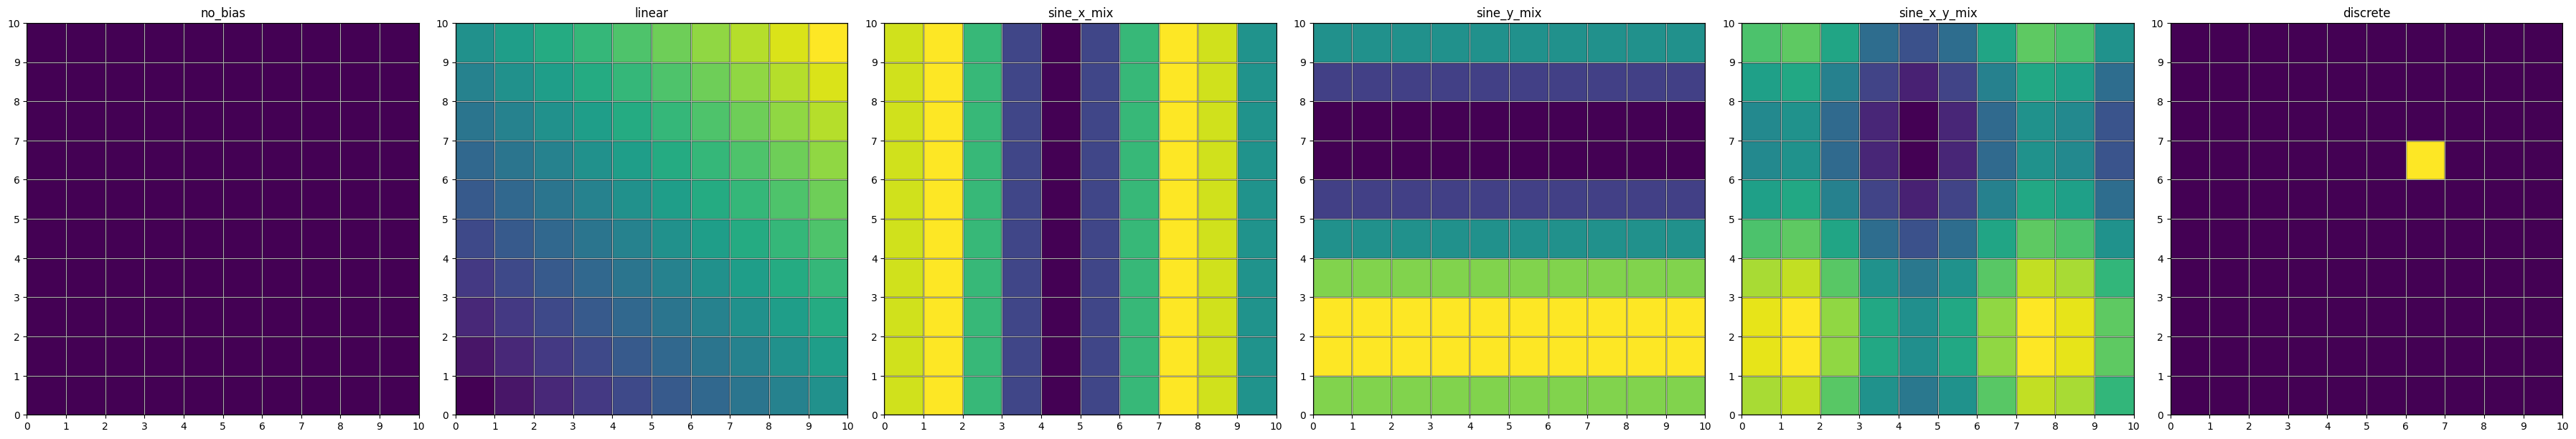

In [3]:
raw_geno, humans = load_data()
geno = raw_geno.copy()
pheno = make_pheno(humans)
show_biases(pheno)

In [4]:
chosen_bias = "discrete"
pheno[chosen_bias] = (pheno[chosen_bias] - pheno[chosen_bias].mean()) / pheno[chosen_bias].std()
G, snp_cols, pcs = _prep_geno_and_pcs(geno, PCs=5)
G.shape, len(snp_cols), pcs.shape

((2000, 8000), 8000, (2000, 5))

In [5]:
values, pcs, ps, HWE_dev = find_snps(geno, pop=humans["populations"], chosen_bias=pheno["discrete"], PCs=5)

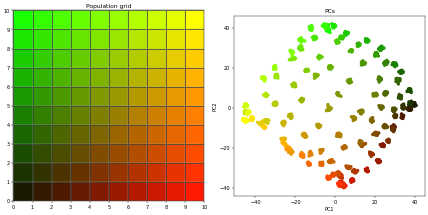

In [6]:
visualize_grid_and_pcs(pcs, humans, dpi=36, s=48)

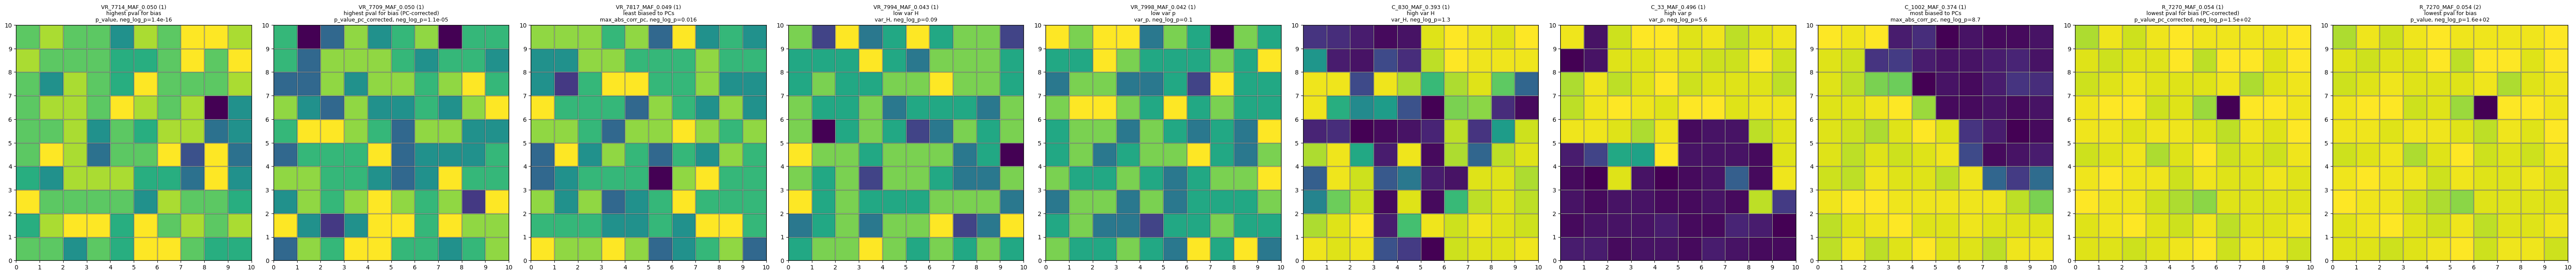

In [7]:
show_top_snps_ordered(humans, geno, values)

In [8]:
chosen_snp = values.loc[
    values["reasons"] == "lowest pval for bias (PC-corrected)", "names"
].iloc[0]

In [9]:
geno, std_params = standardize_and_return_params(geno)

In [11]:
mean_abs_corr, corr_df_sorted, correlated_snps = snp_correlation_analysis(
    geno,chosen_snp,
    top_k=5
)

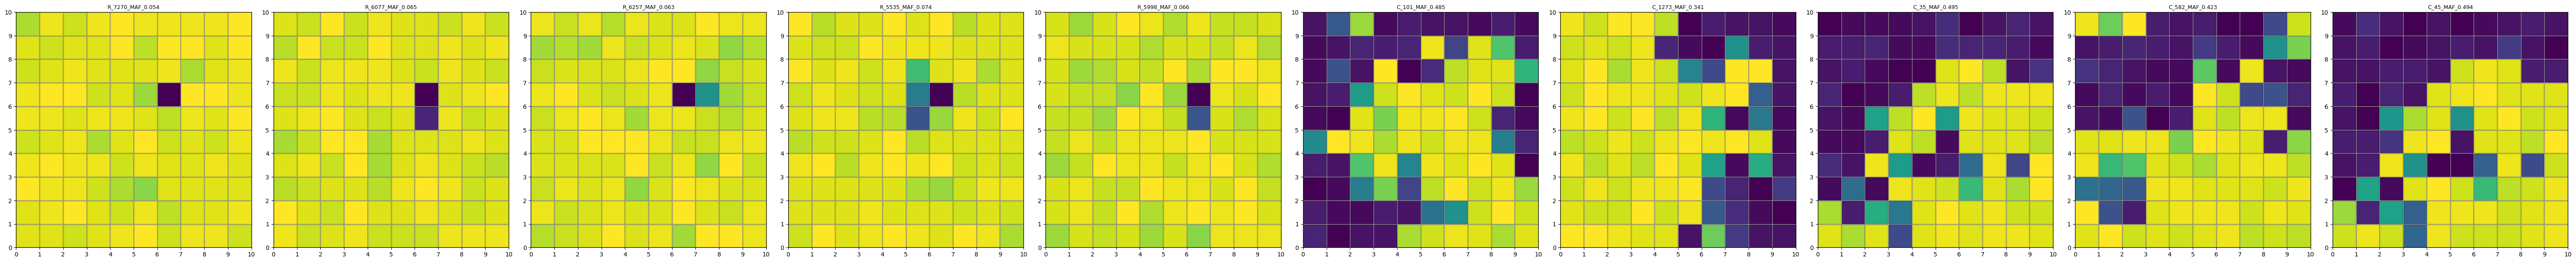

In [12]:
show_corr_snps_ordered(humans, geno, correlated_snps)

# Generate effects